<a href="https://colab.research.google.com/github/santissx/EDA-Titanic/blob/main/EDA_Titanic_Analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import requests

In [38]:
#definimos la url donde esta el dataset a descargar
Url: str = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

#descargamos el dataset
df_titanic = pd.read_csv(Url)


#mostramos las 5 primeras filas
df_titanic.head(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Se observa que en el dataframe se guarda los datos de si sobrevivio como (1) y si fallecio en el incidente como (0), por su parte, se guarda la clase en la que estaba, el genero, la edad, sibsp indica si tenian hermanos o conyuges en el barco o no y cuantos, Parch indica si tenian padres o hijos en el barco y cuantos. fare indica el precio del boleto, embarked indica los puertos donde pudieron haber embarcado, existiendo S=southampton, C= Cherbourg y Q= queenstown, Class es la clase de ticket del pasajero, who indica como se lo identifica (Hombre/mujer/niño), adult_male confirma si es un hombre adulto, deck
no se conoce a que se refiere, embark_town es lo mismo que embarked pero con el nombre completo, alive deja implicito si aun estan vivos o no, alone indica si subieron acompañados al barco

In [39]:
#borrar columnas inutiles/duplicadas

df_titanic = df_titanic.drop(columns=['adult_male', 'embarked', 'alive'])


In [40]:
#mostramos la nueva info del dataset
df_titanic.info()
#podemos observar que deck tiene muchos valores nulos por lo que procederemos a anularlo
df_titanic = df_titanic.drop(columns=['deck'])
#mostramos nuevamente la info del dataset
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   class        891 non-null    object 
 8   who          891 non-null    object 
 9   deck         203 non-null    object 
 10  embark_town  889 non-null    object 
 11  alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(5)
memory usage: 77.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1  

In [41]:
#podemos observar que age tiene valores nulos, por lo que calcularemos la media de dicha columna y rellenaremos los valores faltantes de esta con el fin de reemplazar los valores nulos con esta
media = round (df_titanic["age"].mean(),0)
moda_embark = round (df_titanic["embark_town"].mode(),0)
print(f"{media}")

#rellenamos en el dataset
df_titanic['age'] = df_titanic['age'].fillna(media)
df_titanic['age'] = df_titanic['age'].fillna(moda_embark)

df_titanic.describe()

30.0


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.758889,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002570,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Con este analisis basico podemos decir que:
en promedio sobrevivio el 38,38% de los pasajeros del titanic
que la edad promedio de los pasajeros es de 29 años, teniendo 4 meses de edad el pasajerx y 80 años el de mayor edad
tambien podemos decir que existen 3 tipos de clases, denominadas como 1-2-3
el 52% de los pasajeros asistio con un hermanx o su conyuge
el 38% de los pasajeros tenia padres/hijos en la tripulación
el precio promedio de los boletos fue de 32,20, siendo el boleto mas "barato" gratis y el mas caro costando $512,32



la cantidad de supervivientes del titanic son 
 survived
0    549
1    342
Name: count, dtype: int64 
 Siendo 0 = no y 1 = si


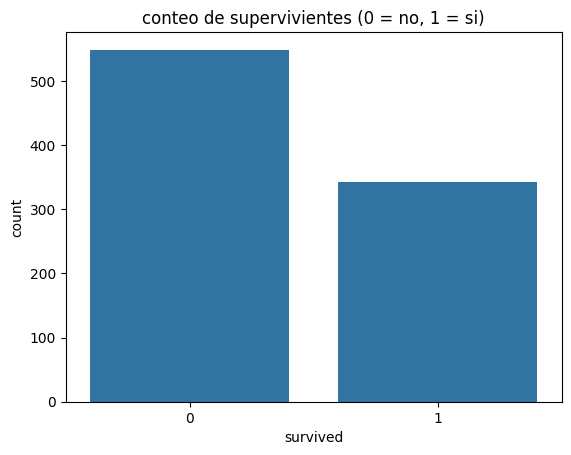

In [42]:
#saber cantidad de personas que sobrevivieron y cantidad que no:
print(f"la cantidad de supervivientes del titanic son \n {df_titanic['survived'].value_counts()} \n Siendo 0 = no y 1 = si")

#se le pasa a seaborn el dataframe como data usando a la columna survived como eje x
sns.countplot(data=df_titanic, x='survived')

#añade titulo al grafico
plt.title('conteo de supervivientes (0 = no, 1 = si)')

#mostrar grafico

plt.show()

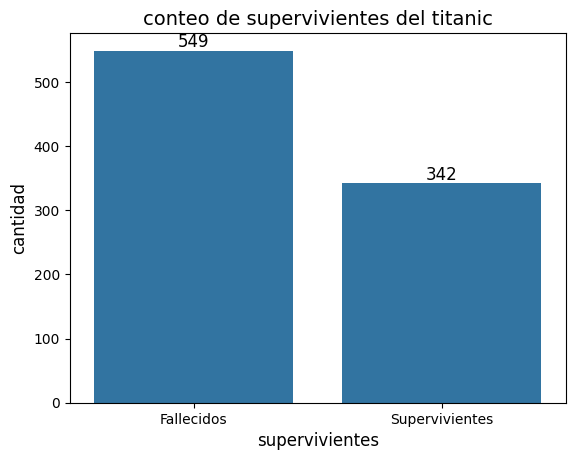

In [43]:
#Opcion 2:
#se guardan los valores por separado
valores_survived = df_titanic['survived'].value_counts()

#Creamos el "diccionario de mapeo" para fallecidos y supervivientes
mapa_nombres = {
  0: 'Fallecidos', 1: 'Supervivientes'}

#se guardan los valores obtenidos con su caratula:
valores_survived = valores_survived.rename(mapa_nombres)

#creamos la figura y los ejes
fig, ax = plt.subplots()

#le pasamos los valor a seaborn
sns.barplot(x=valores_survived.index, y=valores_survived.values, ax=ax)

#le ponemos la cantidad sobre las barras
ax.bar_label(ax.containers[0], fontsize=12)

#titulos para los ejes

ax.set_title('conteo de supervivientes del titanic', fontsize=14)
ax.set_ylabel('cantidad', fontsize=12)
ax.set_xlabel('supervivientes', fontsize=12)

#mostrar grafico
plt.show()

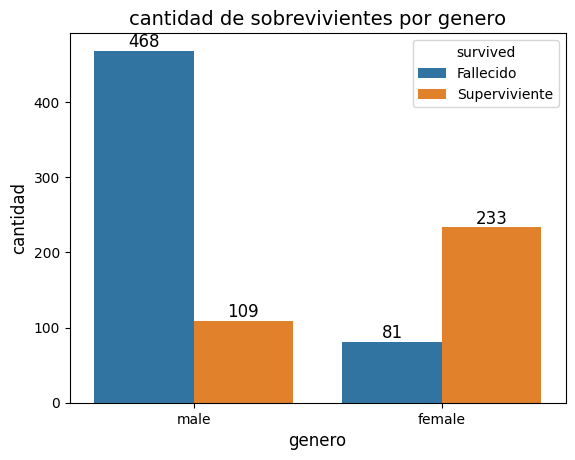

In [44]:
#saber cantidad de gente que sobrevivio segun el genero

#Creamos el "diccionario de mapeo" para renombrar a las columnas del dataset
mapa_nombres = {
  0: 'Fallecidos', 1: 'Supervivientes'}
df_titanic['survived'] = df_titanic['survived'].map({0: 'Fallecido', 1: 'Superviviente'})

#creamos la figura
fig, ax = plt.subplots()


#llamamos a seaborn para imprimir el grafico
sns.countplot(data=df_titanic, x='sex', hue='survived')

#le ponemos la cantidad sobre las barras
for container in ax.containers:
    ax.bar_label(container, fontsize=12)

#le ponemos nombre al grafico y los
ax.set_title ("cantidad de sobrevivientes por genero", fontsize = 14)
ax.set_ylabel ("cantidad", fontsize = 12)
ax.set_xlabel ("genero", fontsize = 12)




#mostrar el grafico
plt.show()

Como puede observasrse en el grafico

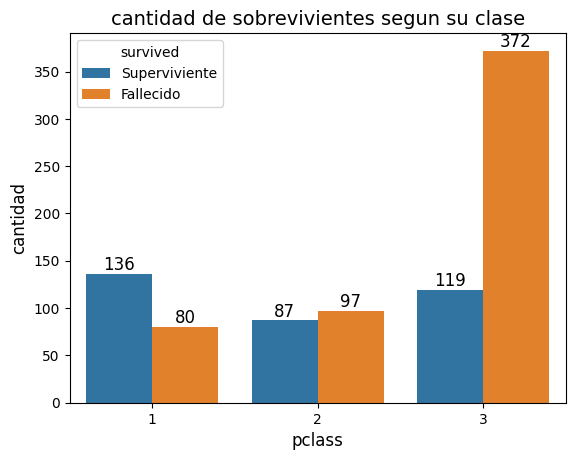

In [45]:

fig2, ax2 = plt.subplots()

#llamamos a seaborn para imprimir el grafico
sns.countplot(data=df_titanic, x='pclass', hue='survived')

#le ponemos la cantidad sobre las barras
for container in ax2.containers:
    ax2.bar_label(container, fontsize=12)

#le ponemos nombre al grafico y los
ax2.set_title ("cantidad de sobrevivientes segun su clase", fontsize = 14)
ax2.set_ylabel ("cantidad", fontsize = 12)
ax2.set_xlabel ("pclass", fontsize = 12)


#mostrar el grafico
plt.show()

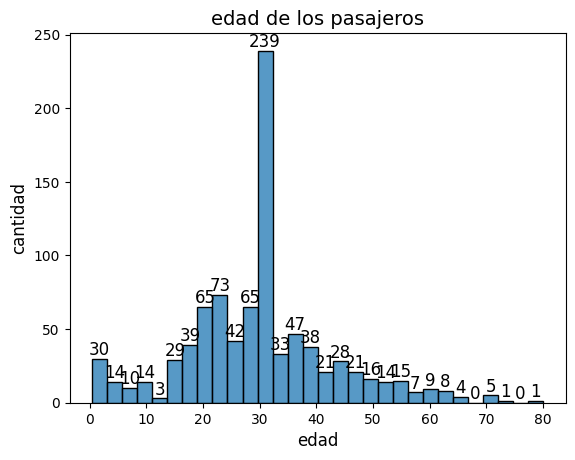

In [46]:

fig3, ax3 = plt.subplots()

#llamamos a seaborn para imprimir el grafico

sns.histplot(data=df_titanic, x='age')

#le ponemos la cantidad sobre las barras
for container in ax3.containers:
    ax3.bar_label(container, fontsize=12)

#le ponemos nombre al grafico y los ejes
ax3.set_title ("edad de los pasajeros", fontsize = 14)
ax3.set_ylabel ("cantidad", fontsize = 12)
ax3.set_xlabel ("edad", fontsize = 12)

plt.show()
